In [1]:
# Import required packages

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import sys
import gc
from pathlib import Path
import logging
from matplotlib.patches import Patch

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [16]:
# Configuration
config = {
    'casr_input_dir': project_root / 'data' / 'input_data' / 'CaSR_SWE' / 'bow_casrv3.2_SWE_P_data.csv',
    'drought_subset': project_root / 'data' / 'output_data' / 'for_paper'/'SWEI'/'bow_casr_swei_8mo_new.csv',
    'shapefile': project_root / 'data' / 'output_data' / 'elevation' / 'Alberta_elevation_combined.shp',
    'output_dir': project_root / 'data' / 'output_plots' / 'for_paper'/'SWEI',
    'output_plots': project_root / 'data' / 'output_plots' / 'for_paper'/'SWEI'
}

In [3]:
# load the CASR data
casr_data = pd.read_csv(config['casr_input_dir'])
display(casr_data.head())

,Grid_id,time,lon,lat,Precipitation,SWE,Elevation_Category
0,1,1980-10-10,-116.1380,51.3346,0.009879,0.878418,2000_2500m
1,1,1982-07-19,-116.1380,51.3346,2.765854,0.515625,2000_2500m
2,2,1983-10-12,-116.1875,51.4191,0.023846,6.875000,2000_2500m
3,2,1980-12-11,-116.1875,51.4191,4.578907,118.125000,2000_2500m
4,2,1981-07-21,-116.1875,51.4191,5.400473,0.000000,2000_2500m


In [8]:
# Enforce allowed seasonal-year range inside the selector
def select_seasonal_data(ts, start_month, end_month, min_year, max_year):
    month = ts.month
    year = ts.year
    if month >= start_month:
        seasonal_year = year
    elif month <= end_month:
        seasonal_year = year - 1
    else:
        return np.nan
    return seasonal_year if (min_year <= seasonal_year <= max_year) else np.nan

# ensure 'time' is datetime
casr_data['time'] = pd.to_datetime(casr_data['time'], errors='coerce')

# compute Seasonal_Year only for valid datetimes to avoid AttributeError
casr_data['Seasonal_Year'] = np.nan
mask = casr_data['time'].notna()
casr_data.loc[mask, 'Seasonal_Year'] = (
    casr_data.loc[mask, 'time']
    .apply(lambda ts: select_seasonal_data(ts, start_month=10, end_month=5, min_year=1980, max_year=2023))
)
# Remove rows where Seasonal_Year is NaN (outside the allowed data range)
casr_data = casr_data.dropna(subset=['Seasonal_Year'])
display(casr_data.head())

,Grid_id,time,lon,lat,Precipitation,SWE,Elevation_Category,Seasonal_Year
0,1,1980-10-10,-116.1380,51.3346,0.009879,0.878418,2000_2500m,1980.0
2,2,1983-10-12,-116.1875,51.4191,0.023846,6.875000,2000_2500m,1983.0
3,2,1980-12-11,-116.1875,51.4191,4.578907,118.125000,2000_2500m,1980.0
5,2,1982-10-29,-116.1875,51.4191,1.777088,23.125000,2000_2500m,1982.0
6,2,1982-01-18,-116.1875,51.4191,1.890419,145.000000,2000_2500m,1981.0


In [10]:
# take cum sum of Precipitation and mean SWE over each Seasonal_Year, per grid
SD_clasification_data = casr_data.sort_values(
    ['Grid_id', 'Seasonal_Year', 'time']
).copy()

SD_clasification_data['Cumulative_Precipitation'] = (
    SD_clasification_data
    .groupby(['Grid_id', 'Seasonal_Year'])['Precipitation']
    .cumsum()
)

# get max cumulative Precipitation and mean SWE for each grid and Seasonal_Year
seasonal_maxcumP_meanSWE = (
    SD_clasification_data
    .groupby(['Grid_id', 'Seasonal_Year', 'lon', 'lat', 'Elevation_Category'], as_index=False)
    .agg(
        Max_Cumulative_Precipitation=('Cumulative_Precipitation', 'max'),
        Mean_SWE=('SWE', 'mean')
    )
)

display(seasonal_maxcumP_meanSWE.head())

,Grid_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE
0,1,1980.0,-116.138,51.3346,2000_2500m,330.692535,124.720065
1,1,1981.0,-116.138,51.3346,2000_2500m,321.687604,141.946829
2,1,1982.0,-116.138,51.3346,2000_2500m,231.587842,140.776336
3,1,1983.0,-116.138,51.3346,2000_2500m,272.967472,114.779913
4,1,1984.0,-116.138,51.3346,2000_2500m,258.220625,110.846370


In [12]:
mean_cumP_by_elev = seasonal_maxcumP_meanSWE.groupby('Elevation_Category')['Max_Cumulative_Precipitation'].mean().reset_index()
mean_cumP_by_elev = mean_cumP_by_elev.rename(columns={'Max_Cumulative_Precipitation': 'mean_max_cumulative_P'})

display(mean_cumP_by_elev)

,Elevation_Category,mean_max_cumulative_P
0,1000_1500m,198.791563
1,1500_2000m,254.289177
2,2000_2500m,322.600551
3,500_1000m,150.882044


In [13]:
# Merge the mean back to the main DataFrame
onset_to_peak_mean_filtered = seasonal_maxcumP_meanSWE.merge(
    mean_cumP_by_elev,
    on='Elevation_Category',
    how='left'
)

display(onset_to_peak_mean_filtered)

,Grid_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P
0,1,1980.0,-116.1380,51.3346,2000_2500m,330.692535,124.720065,322.600551
1,1,1981.0,-116.1380,51.3346,2000_2500m,321.687604,141.946829,322.600551
2,1,1982.0,-116.1380,51.3346,2000_2500m,231.587842,140.776336,322.600551
3,1,1983.0,-116.1380,51.3346,2000_2500m,272.967472,114.779913,322.600551
4,1,1984.0,-116.1380,51.3346,2000_2500m,258.220625,110.846370,322.600551
...,...,...,...,...,...,...,...,...
11303,257,2019.0,-111.6202,50.0960,500_1000m,143.209873,2.395867,150.882044
11304,257,2020.0,-111.6202,50.0960,500_1000m,123.811036,2.383157,150.882044
11305,257,2021.0,-111.6202,50.0960,500_1000m,87.313718,1.164792,150.882044
11306,257,2022.0,-111.6202,50.0960,500_1000m,124.308624,3.057855,150.882044


In [14]:
# Calculations to plot graphs
onset_to_peak_mean_filtered['SWE_P_ratio'] = (
    onset_to_peak_mean_filtered['Mean_SWE'] /
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation']
)

onset_to_peak_mean_filtered['Cum_P_anomaly'] = (
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation'] -
    onset_to_peak_mean_filtered['mean_max_cumulative_P']
)

display(onset_to_peak_mean_filtered)

,Grid_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P,SWE_P_ratio,Cum_P_anomaly
0,1,1980.0,-116.1380,51.3346,2000_2500m,330.692535,124.720065,322.600551,0.377148,8.091984
1,1,1981.0,-116.1380,51.3346,2000_2500m,321.687604,141.946829,322.600551,0.441257,-0.912947
2,1,1982.0,-116.1380,51.3346,2000_2500m,231.587842,140.776336,322.600551,0.607874,-91.012709
3,1,1983.0,-116.1380,51.3346,2000_2500m,272.967472,114.779913,322.600551,0.420489,-49.633079
4,1,1984.0,-116.1380,51.3346,2000_2500m,258.220625,110.846370,322.600551,0.429270,-64.379926
...,...,...,...,...,...,...,...,...,...,...
11303,257,2019.0,-111.6202,50.0960,500_1000m,143.209873,2.395867,150.882044,0.016730,-7.672171
11304,257,2020.0,-111.6202,50.0960,500_1000m,123.811036,2.383157,150.882044,0.019248,-27.071008
11305,257,2021.0,-111.6202,50.0960,500_1000m,87.313718,1.164792,150.882044,0.013340,-63.568326
11306,257,2022.0,-111.6202,50.0960,500_1000m,124.308624,3.057855,150.882044,0.024599,-26.573420


In [15]:
# take mean over Elevation_Category and Seasonal_Year
final_classification_data = (
    onset_to_peak_mean_filtered
    .groupby(['Elevation_Category', 'Seasonal_Year'], as_index=False)
    .agg(
        Avg_SWE_P_ratio=('SWE_P_ratio', 'mean'),
        Avg_Cum_P_anomaly=('Cum_P_anomaly', 'mean')
    )
)
display(final_classification_data)

,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly
0,1000_1500m,1980.0,0.017906,43.219919
1,1000_1500m,1981.0,0.043095,-27.761347
2,1000_1500m,1982.0,0.027718,-41.996265
3,1000_1500m,1983.0,0.037195,-60.840708
4,1000_1500m,1984.0,0.054673,-81.794527
...,...,...,...,...
171,500_1000m,2019.0,0.064201,6.323612
172,500_1000m,2020.0,0.055116,-20.557390
173,500_1000m,2021.0,0.022948,-64.727040
174,500_1000m,2022.0,0.067483,-35.737448


In [17]:
# load drought_subset data
drought_subset = pd.read_csv(config['drought_subset'])
display(drought_subset)

,index,station_id,time,SWE_monthly,Seasonal_Year,SWE_8mo,month,Gringorten_p,SWEI,lon,lat,Elevation_Category
0,0,1,1981-05-01,5.072801e+03,1980,30306.975814,5,0.556664,0.142516,-116.1380,51.3346,2000_2500m
1,1,1,1982-05-01,7.276954e+03,1981,34493.079364,5,0.737987,0.637153,-116.1380,51.3346,2000_2500m
2,2,1,1983-05-01,5.607820e+03,1982,34208.649527,5,0.692656,0.503394,-116.1380,51.3346,2000_2500m
3,3,1,1984-05-01,5.777537e+03,1983,28006.298830,5,0.420671,-0.200177,-116.1380,51.3346,2000_2500m
4,4,1,1985-05-01,4.583076e+03,1984,26935.667961,5,0.352675,-0.378110,-116.1380,51.3346,2000_2500m
...,...,...,...,...,...,...,...,...,...,...,...,...
11303,11303,257,2020-05-01,1.048005e-10,2019,584.591553,5,0.284678,-0.569000,-111.6202,50.0960,500_1000m
11304,11304,257,2021-05-01,1.137207e+01,2020,579.107177,5,0.239347,-0.708404,-111.6202,50.0960,500_1000m
11305,11305,257,2022-05-01,9.515785e-11,2021,283.044342,5,0.012693,-2.235488,-111.6202,50.0960,500_1000m
11306,11306,257,2023-05-01,1.049957e-10,2022,743.058776,5,0.466002,-0.085324,-111.6202,50.0960,500_1000m


In [18]:
# avaerage SWEI over the Elevation categories, month and seasonal year
swei_8mo_avg = (
    drought_subset
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_8mo=('SWEI', 'mean')
    )
)

display(swei_8mo_avg.head(15))

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo
0,1000_1500m,1980,5,-0.778473
1,1000_1500m,1981,5,0.320094
2,1000_1500m,1982,5,-0.942805
3,1000_1500m,1983,5,-0.356098
4,1000_1500m,1984,5,-0.147442
5,1000_1500m,1985,5,0.314323
6,1000_1500m,1986,5,-0.474813
7,1000_1500m,1987,5,-1.338402
8,1000_1500m,1988,5,0.898300
9,1000_1500m,1989,5,0.113604


In [20]:
#print snow drought years for each elevation category
for elev_cat in swei_8mo_avg['Elevation_Category'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    print(f"Elevation Category: {elev_cat}, Drought Years (Avg SWEI <= -0.5): {drought_years.tolist()}")

# Create a dataframe with drought years for each elevation category
drought_data = []
for elev_cat in swei_8mo_avg['Elevation_Category'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    drought_data.append({
        'Elevation_Category': elev_cat,
        'Drought_Years': sorted(drought_years.tolist())
    })

drought_years_df = pd.DataFrame(drought_data)

# save the drought years dataframe to a CSV file
drought_years_df.to_csv(config["output_dir"] / "Drought_Years_by_Elevation_new1.csv", index=False)  

display(drought_years_df)

Elevation Category: 1000_1500m, Drought Years (Avg SWEI <= -0.5): [1980, 1982, 1987, 1991, 1993, 1994, 1998, 2000, 2004, 2005, 2007, 2011, 2015]
Elevation Category: 1500_2000m, Drought Years (Avg SWEI <= -0.5): [1980, 1991, 1993, 1994, 1998, 2000, 2002, 2004, 2005, 2006, 2007, 2011, 2015]
Elevation Category: 2000_2500m, Drought Years (Avg SWEI <= -0.5): [1987, 1996, 1997, 1998, 2000, 2002, 2004, 2005, 2009, 2011, 2015]
Elevation Category: 500_1000m, Drought Years (Avg SWEI <= -0.5): [1994, 1997, 1998, 2000, 2004, 2005, 2006, 2011, 2015, 2016, 2018, 2021, 2023]


,Elevation_Category,Drought_Years
0,1000_1500m,"[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200..."
1,1500_2000m,"[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200..."
2,2000_2500m,"[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200..."
3,500_1000m,"[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201..."


In [21]:
# Expand drought years to long format: one row per elevation class and drought year
# This is safer than keeping years as lists during the merge.
drought_years_long = (
    drought_years_df
    .explode("Drought_Years")
    .rename(columns={"Drought_Years": "Seasonal_Year"})
    .dropna(subset=["Seasonal_Year"])
    .copy()
)

drought_years_long["Seasonal_Year"] = drought_years_long["Seasonal_Year"].astype(int)
drought_years_long = drought_years_long[["Elevation_Category", "Seasonal_Year"]].drop_duplicates()

display(drought_years_long.head())
print("Number of SWEI drought year/elevation combinations:", len(drought_years_long))

,Elevation_Category,Seasonal_Year
0,1000_1500m,1980
0,1000_1500m,1982
0,1000_1500m,1987
0,1000_1500m,1991
0,1000_1500m,1993


Number of SWEI drought year/elevation combinations: 50


In [22]:
# Keep all classification variables, but mark which years are SWEI drought years.
classification_all_years = final_classification_data.copy()
classification_all_years["Seasonal_Year"] = classification_all_years["Seasonal_Year"].astype(int)

classification_all_years = classification_all_years.merge(
    drought_years_long.assign(is_swei_drought=True),
    on=["Elevation_Category", "Seasonal_Year"],
    how="left"
)
classification_all_years["is_swei_drought"] = classification_all_years["is_swei_drought"].fillna(False)

# Only SWEI drought years go into the k-means classification.
drought_classification_data = classification_all_years[
    classification_all_years["is_swei_drought"]
].copy()

if drought_classification_data.empty:
    raise ValueError("No matching SWEI drought years found. Check Elevation_Category names and Seasonal_Year values.")

# Check whether any drought years from the SWEI file were not found in the classification table.
matched_keys = set(zip(drought_classification_data["Elevation_Category"], drought_classification_data["Seasonal_Year"]))
requested_keys = set(zip(drought_years_long["Elevation_Category"], drought_years_long["Seasonal_Year"]))
missing_keys = sorted(requested_keys - matched_keys)

print("Matched SWEI drought year/elevation combinations:", len(matched_keys))
print("Missing combinations from classification data:", len(missing_keys))
if missing_keys:
    print("First missing combinations:", missing_keys[:20])

display(drought_classification_data.head())

Matched SWEI drought year/elevation combinations: 50
Missing combinations from classification data: 0


C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_18748\3054200154.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  classification_all_years["is_swei_drought"] = classification_all_years["is_swei_drought"].fillna(False)


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought
0,1000_1500m,1980,0.017906,43.219919,True
2,1000_1500m,1982,0.027718,-41.996265,True
7,1000_1500m,1987,0.045110,-111.069442,True
11,1000_1500m,1991,0.029284,-53.264281,True
13,1000_1500m,1993,0.027118,-28.782534,True


In [23]:
# Standardize variables within each elevation category, using drought years only.
# This makes the workflow transferable across Alberta, Bow River, or other datasets.
def zscore_by_group(df, group_col, value_col, output_col):
    def zscore(x):
        std = x.std(ddof=1)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(x)), index=x.index)
        return (x - x.mean()) / std

    df[output_col] = df.groupby(group_col)[value_col].transform(zscore)
    return df


drought_classification_data = zscore_by_group(
    drought_classification_data,
    "Elevation_Category",
    "Avg_Cum_P_anomaly",
    "cum_P_anomaly_z"
)

drought_classification_data = zscore_by_group(
    drought_classification_data,
    "Elevation_Category",
    "Avg_SWE_P_ratio",
    "Avg_SWE_P_ratio_z"
)

# Remove any rows with missing/infinite features before clustering.
feature_cols = ["Avg_SWE_P_ratio_z", "cum_P_anomaly_z"]
drought_classification_data = drought_classification_data.replace([np.inf, -np.inf], np.nan)
drought_classification_data = drought_classification_data.dropna(subset=feature_cols).copy()

if len(drought_classification_data) < 3:
    raise ValueError("At least 3 drought-year rows are needed for 3-cluster k-means.")

display(drought_classification_data[["Elevation_Category", "Seasonal_Year"] + feature_cols].head())

,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio_z,cum_P_anomaly_z
0,1000_1500m,1980,-0.874797,1.400310
2,1000_1500m,1982,0.298311,-0.383937
7,1000_1500m,1987,2.377594,-1.830183
11,1000_1500m,1991,0.485491,-0.619865
13,1000_1500m,1993,0.226594,-0.107269


In [24]:
# K-means classification of drought years only.
# n_init is fixed for reproducibility; cluster labels are assigned from centroids below.
n_clusters = min(3, len(drought_classification_data))

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=50
)

drought_classification_data["cluster"] = kmeans.fit_predict(
    drought_classification_data[feature_cols]
)

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)
centers["cluster"] = np.arange(n_clusters)

print("Cluster centers in standardized drought-year space:")
display(centers)

Cluster centers in standardized drought-year space:


c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,Avg_SWE_P_ratio_z,cum_P_anomaly_z,cluster
0,-0.832127,1.029864,0
1,1.472828,-0.950277,1
2,-0.058230,-0.384976,2


In [27]:
# Automatically assign physical snow-drought type names from cluster centroids.
# Logic:
# - Warm: relatively low SWE/P, relatively wet/normal precipitation anomaly
# - Dry: relatively high SWE/P, relatively dry precipitation anomaly
# - Warm & Dry: relatively low SWE/P and relatively dry precipitation anomaly
#
# This avoids hard-coding cluster numbers, which change between datasets.

def assign_cluster_names_from_centers(centers_df):
    centers_df = centers_df.copy()
    centers_df["cluster_name"] = None

    if len(centers_df) == 3:
        # Warm & Dry should be the cluster with the smallest combined score:
        # low SWE/P and low precipitation anomaly.
        centers_df["warm_dry_score"] = (
            centers_df["Avg_SWE_P_ratio_z"] + centers_df["cum_P_anomaly_z"]
        )
        warm_dry_cluster = centers_df.loc[centers_df["warm_dry_score"].idxmin(), "cluster"]
        centers_df.loc[centers_df["cluster"] == warm_dry_cluster, "cluster_name"] = "Warm & Dry"

        remaining = centers_df[centers_df["cluster_name"].isna()].copy()

        # Of the remaining two clusters:
        # lower SWE/P = Warm, lower precipitation anomaly = Dry.
        warm_cluster = remaining.loc[remaining["Avg_SWE_P_ratio_z"].idxmin(), "cluster"]
        dry_cluster = remaining.loc[remaining["cum_P_anomaly_z"].idxmin(), "cluster"]

        # If both rules choose the same cluster, use the opposite cluster for Dry.
        if warm_cluster == dry_cluster:
            other_clusters = remaining.loc[remaining["cluster"] != warm_cluster, "cluster"].tolist()
            dry_cluster = other_clusters[0]

        centers_df.loc[centers_df["cluster"] == warm_cluster, "cluster_name"] = "Warm"
        centers_df.loc[centers_df["cluster"] == dry_cluster, "cluster_name"] = "Dry"

    else:
        # Fallback for tiny datasets with fewer than 3 clusters.
        # Label each cluster using simple physical rules around the centroid signs.
        for idx, row in centers_df.iterrows():
            low_swep = row["Avg_SWE_P_ratio_z"] <= 0
            low_p = row["cum_P_anomaly_z"] <= 0
            if low_swep and low_p:
                label = "Warm & Dry"
            elif low_swep and not low_p:
                label = "Warm"
            elif not low_swep and low_p:
                label = "Dry"
            else:
                # Drought years should rarely fall here; choose least misleading label.
                label = "Warm"
            centers_df.loc[idx, "cluster_name"] = label

    return centers_df[["cluster", "cluster_name"]]


cluster_name_map = assign_cluster_names_from_centers(centers)
drought_classification_data = drought_classification_data.merge(
    cluster_name_map,
    on="cluster",
    how="left"
)

print("Automatic cluster-name map:")
display(cluster_name_map)

# Clean up duplicate cluster-name columns created by rerunning the merge cell.
if "cluster_name_x" in drought_classification_data.columns and "cluster_name_y" in drought_classification_data.columns:
    drought_classification_data["cluster_name"] = drought_classification_data["cluster_name_y"].combine_first(
        drought_classification_data["cluster_name_x"]
    )
    drought_classification_data = drought_classification_data.drop(columns=["cluster_name_x", "cluster_name_y"])
elif "cluster_name_y" in drought_classification_data.columns and "cluster_name" not in drought_classification_data.columns:
    drought_classification_data = drought_classification_data.rename(columns={"cluster_name_y": "cluster_name"})

display(
    drought_classification_data[
        ["Elevation_Category", "Seasonal_Year", "Avg_SWE_P_ratio", "Avg_Cum_P_anomaly", "cluster", "cluster_name"]
    ].sort_values(["Elevation_Category", "Seasonal_Year"])
)

Automatic cluster-name map:


,cluster,cluster_name
0,0,Warm
1,1,Dry
2,2,Warm & Dry


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,cluster,cluster_name
0,1000_1500m,1980,0.017906,43.219919,0,Warm
1,1000_1500m,1982,0.027718,-41.996265,2,Warm & Dry
2,1000_1500m,1987,0.045110,-111.069442,1,Dry
3,1000_1500m,1991,0.029284,-53.264281,2,Warm & Dry
4,1000_1500m,1993,0.027118,-28.782534,2,Warm & Dry
5,1000_1500m,1994,0.015853,14.969064,0,Warm
6,1000_1500m,1998,0.017232,-10.516967,0,Warm
7,1000_1500m,2000,0.033864,-61.063646,1,Dry
8,1000_1500m,2004,0.026434,-46.596033,2,Warm & Dry
9,1000_1500m,2005,0.021352,-51.521720,2,Warm & Dry


In [29]:
# Add drought-type labels back to all years.
# SWEI drought years receive Warm, Dry, or Warm & Dry.
# Non-SWEI-drought years are Normal.
classified_drought_years = drought_classification_data[
    ["Elevation_Category", "Seasonal_Year", "cluster_name", "cluster"]
].copy()

classification_all_years = classification_all_years.drop(columns=["cluster_name", "cluster"], errors="ignore")
classification_all_years = classification_all_years.merge(
    classified_drought_years,
    on=["Elevation_Category", "Seasonal_Year"],
    how="left"
)
classification_all_years["cluster_name"] = classification_all_years["cluster_name"].fillna("Normal")
classification_all_years.loc[classification_all_years["is_swei_drought"] == False, "cluster"] = -1

# This check should be zero: every SWEI drought year should now have a drought type.
unclassified_droughts = classification_all_years[
    classification_all_years["is_swei_drought"] & classification_all_years["cluster_name"].isna()
]
print("Unclassified SWEI drought years:", len(unclassified_droughts))

display(classification_all_years.head())

Unclassified SWEI drought years: 0


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought,cluster_name,cluster
0,1000_1500m,1980,0.017906,43.219919,True,Warm,0.0
1,1000_1500m,1981,0.043095,-27.761347,False,Normal,-1.0
2,1000_1500m,1982,0.027718,-41.996265,True,Warm & Dry,2.0
3,1000_1500m,1983,0.037195,-60.840708,False,Normal,-1.0
4,1000_1500m,1984,0.054673,-81.794527,False,Normal,-1.0


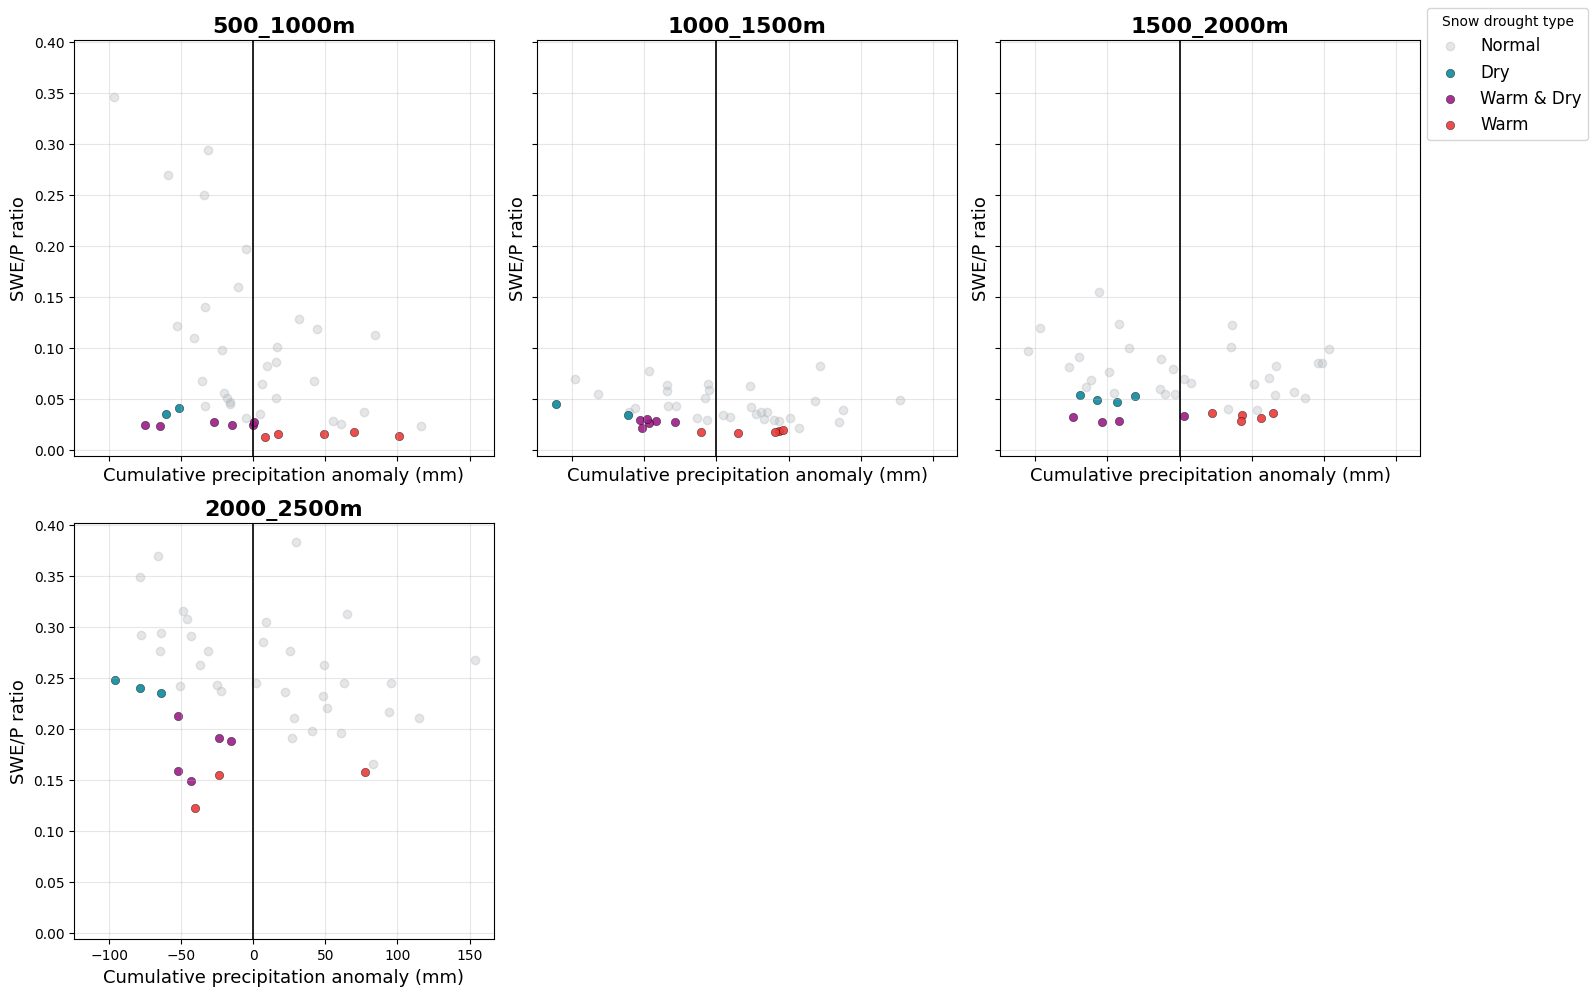

In [31]:
# Plot drought-year k-means classification in physical variable space.
cluster_colors = {
    "Warm": "#EB3A3A",
    "Warm & Dry": "#9C1C87",
    "Dry": "#0C889E",
    "Normal": "#B2B8BD",
}

elev_order = ["0_500m", "500_1000m", "1000_1500m", "1500_2000m", "2000_2500m"]
elevations_ordered = [e for e in elev_order if e in classification_all_years["Elevation_Category"].unique()]

ncols = 3
nrows = int(np.ceil(len(elevations_ordered) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for i, elev in enumerate(elevations_ordered):
    ax = axes[i]
    elev_all = classification_all_years[classification_all_years["Elevation_Category"] == elev]

    # Plot non-drought years lightly as background.
    normal_points = elev_all[elev_all["cluster_name"] == "Normal"]
    ax.scatter(
        normal_points["Avg_Cum_P_anomaly"],
        normal_points["Avg_SWE_P_ratio"],
        color=cluster_colors["Normal"],
        alpha=0.35,
        label="Normal" if i == 0 else ""
    )

    # Plot classified drought years on top.
    for cname in ["Dry", "Warm & Dry", "Warm"]:
        pts = elev_all[elev_all["cluster_name"] == cname]
        ax.scatter(
            pts["Avg_Cum_P_anomaly"],
            pts["Avg_SWE_P_ratio"],
            color=cluster_colors[cname],
            alpha=0.9,
            edgecolor="black",
            linewidth=0.3,
            label=cname if i == 0 else ""
        )

    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_title(elev, fontsize=16, fontweight="bold")
    ax.set_xlabel("Cumulative precipitation anomaly (mm)", fontsize=13)
    ax.set_ylabel("SWE/P ratio", fontsize=13)
    ax.grid(True, alpha=0.3)

for j in range(len(elevations_ordered), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Snow drought type", loc="upper right", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig(config['output_plots'] / 'Snow_Drought_Classification_by_Elevation_clean.png', dpi=1000, bbox_inches='tight')
plt.show()

In [33]:
# Summary table: drought years separated by type, plus any unmatched/missing years.
# unmatched should be empty unless a SWEI drought year is missing from classification_all_years.

type_to_col = {
    "Dry": "dry",
    "Warm & Dry": "dry&warm",
    "Warm": "warm",
}

summary_rows = []
for elev in elevations_ordered:
    row = {"Elevation_Category": elev}

    requested = set(
        drought_years_long.loc[drought_years_long["Elevation_Category"] == elev, "Seasonal_Year"]
        .dropna()
        .astype(int)
        .tolist()
    )

    matched_for_elev = set(
        classification_all_years.loc[
            (classification_all_years["Elevation_Category"] == elev) &
            (classification_all_years["is_swei_drought"]),
            "Seasonal_Year"
        ].dropna().astype(int).tolist()
    )

    assigned = set()
    for cname, col in type_to_col.items():
        years = classification_all_years.loc[
            (classification_all_years["Elevation_Category"] == elev) &
            (classification_all_years["cluster_name"] == cname),
            "Seasonal_Year"
        ].dropna().astype(int).unique().tolist()
        years = sorted(years)
        row[col] = years
        assigned.update(years)

    row["Drought_Years"] = sorted(requested)
    row["unmatched"] = sorted(requested - assigned)
    row["missing_from_classification_data"] = sorted(requested - matched_for_elev)
    summary_rows.append(row)

sd_years_df = pd.DataFrame(summary_rows)
display(sd_years_df)

# Optional export
# sd_years_df.to_csv(config['output_dir'] / 'Snow_Drought_Years_by_Type_clean.csv', index=False)

,Elevation_Category,dry,dry&warm,warm,Drought_Years,unmatched,missing_from_classification_data
0,500_1000m,"[2004, 2018]","[1997, 1998, 2000, 2015, 2016, 2021]","[1994, 2005, 2006, 2011, 2023]","[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201...",[],[]
1,1000_1500m,"[1987, 2000]","[1982, 1991, 1993, 2004, 2005, 2015]","[1980, 1994, 1998, 2007, 2011]","[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200...",[],[]
2,1500_2000m,"[1991, 1993, 2000, 2015]","[1998, 2004, 2005, 2006]","[1980, 1994, 2002, 2007, 2011]","[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200...",[],[]
3,2000_2500m,"[1987, 2000, 2009]","[1996, 1998, 2004, 2005, 2015]","[1997, 2002, 2011]","[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200...",[],[]


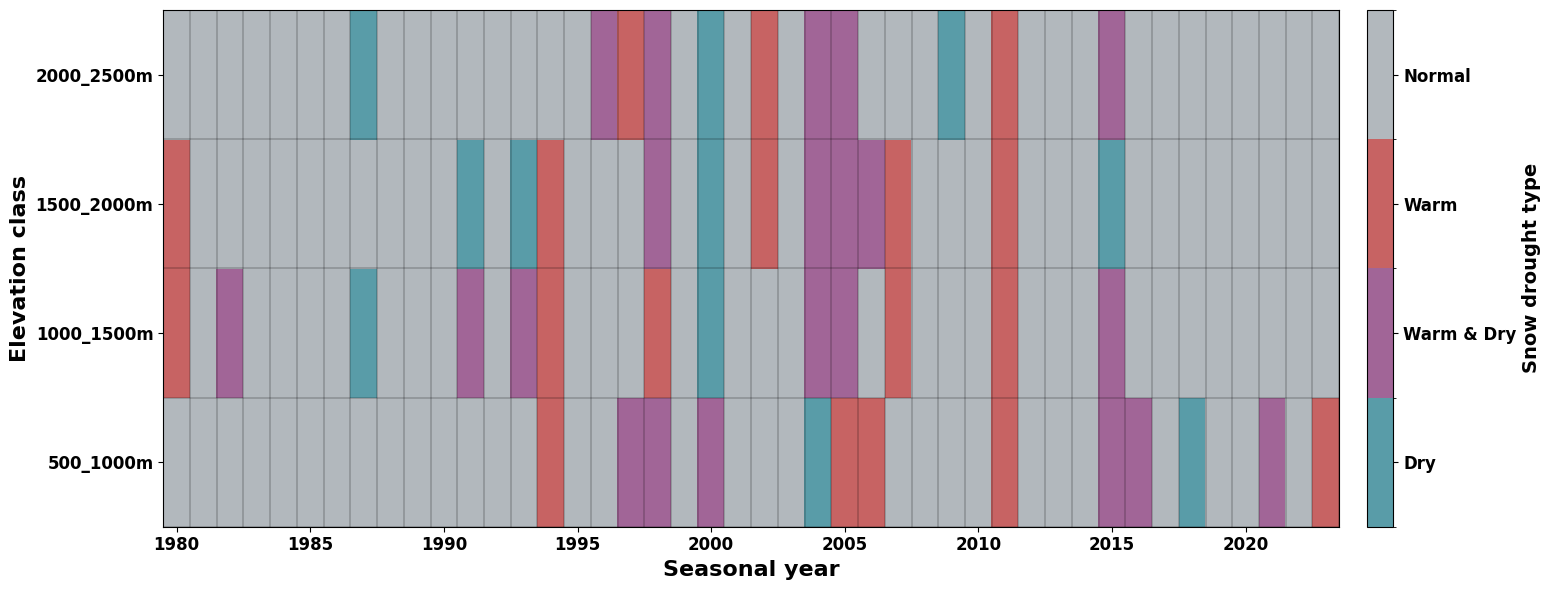

In [35]:
# Heatmap of final snow drought classification.
# Normal = years that are not SWEI drought years.
drought_type_colors = {
    "Dry": "#599CA8",
    "Warm & Dry": "#A16597",
    "Warm": "#C76363",
    "Normal": "#B2B8BD",
}

class_to_value = {
    "Dry": 1,
    "Warm & Dry": 2,
    "Warm": 3,
    "Normal": 4,
}

plot_df = classification_all_years.copy()
plot_df["type_value"] = plot_df["cluster_name"].map(class_to_value)

all_years = sorted(plot_df["Seasonal_Year"].dropna().astype(int).unique())
elevations_ordered = [e for e in elev_order if e in plot_df["Elevation_Category"].unique()]

heatmap_data = np.full((len(elevations_ordered), len(all_years)), np.nan)
for i, elev in enumerate(elevations_ordered):
    elev_df = plot_df[plot_df["Elevation_Category"] == elev]
    year_to_value = dict(zip(elev_df["Seasonal_Year"].astype(int), elev_df["type_value"]))
    for j, year in enumerate(all_years):
        heatmap_data[i, j] = year_to_value.get(year, np.nan)

cmap = ListedColormap([
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"],
])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, norm=norm)

# X-axis ticks every 5 years
all_years_arr = np.array(all_years)
tick_years = np.arange(all_years_arr.min(), all_years_arr.max() + 1, 5)
tick_pos = [np.where(all_years_arr == y)[0][0] for y in tick_years if y in all_years_arr]
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(y) for y in tick_years if y in all_years_arr], fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(elevations_ordered)))
ax.set_yticklabels(elevations_ordered, fontsize=12, fontweight="bold")
ax.invert_yaxis()

ax.set_xlabel("Seasonal year", fontsize=16, fontweight="bold")
ax.set_ylabel("Elevation class", fontsize=16, fontweight="bold")

# Grid lines between cells
ax.set_xticks(np.arange(-0.5, len(all_years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(elevations_ordered), 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, ticks=[1, 2, 3, 4], pad=0.02)
cbar.set_ticklabels(["Dry", "Warm & Dry", "Warm", "Normal"], fontsize=12, fontweight="bold")
cbar.set_label("Snow drought type", fontsize=14, fontweight="bold")

plt.tight_layout()
# plt.savefig(config['output_plots'] / 'Snow_Drought_Classification_Heatmap_clean.png', dpi=1000, bbox_inches='tight')
plt.show()